In [2]:
import pandas as pd
import numpy as np

### Load single-cell data

In [8]:
%%time
df = pd.read_pickle('/Users/dayn/data/macrohet_mac/sc_df.pkl')


CPU times: user 786 ms, sys: 698 ms, total: 1.48 s
Wall time: 2.65 s


In [9]:
df['mtb_origin'].unique()

array(['Undefined', 'Growth', 'Transfer', 'Uptake', 'Junk', 'Unknown'],
      dtype=object)

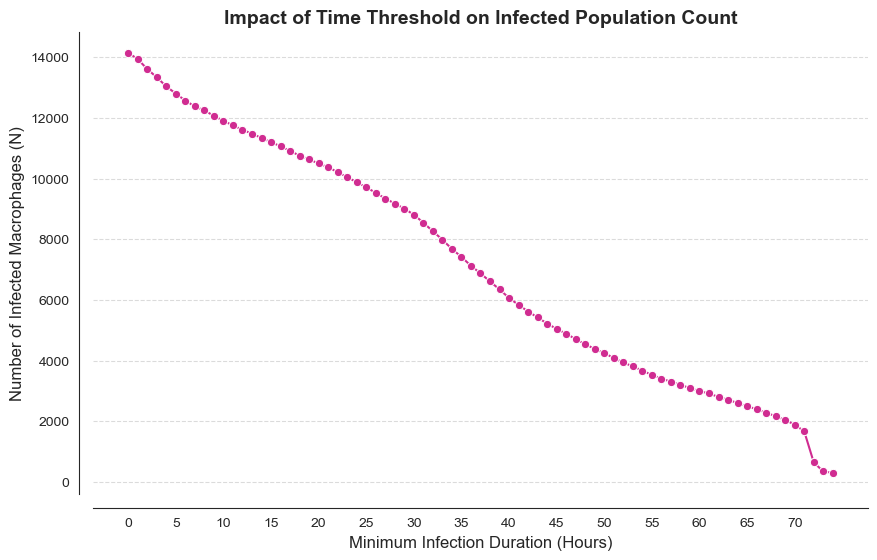

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the difference in time between consecutive rows for each ID
df['dt'] = df.groupby('ID')['Time (hours)'].diff()

# Fill the first row of each track (which will be NaN) with 0 or the median interval
df['dt'] = df['dt'].fillna(0)

# 1. Pre-calculate the total infected duration per ID
# This avoids re-calculating the sum inside the loop
infected_duration = df[df['Infection Status'] == 1].groupby('ID')['dt'].sum()

# 2. Iterate through thresholds 0 to 35
thresholds = range(0, 75)
counts = []

for n_hrs in thresholds:
    n_infected = len(infected_duration[infected_duration >= n_hrs])
    counts.append(n_infected)

# 3. Create DataFrame for plotting
plot_data = pd.DataFrame({'n_hours': thresholds, 'N_infected': counts})

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Line plot using your custom color palette
sns.lineplot(data=plot_data, x='n_hours', y='N_infected', color='#d02c91', marker='o')

# Formatting
plt.title('Impact of Time Threshold on Infected Population Count', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Infection Duration (Hours)', fontsize=12)
plt.ylabel('Number of Infected Macrophages (N)', fontsize=12)
plt.xticks(range(0, 75, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

sns.despine(offset=10)
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/misc/infected_time_threshold.pdf', 
            bbox_inches='tight',
            dpi=314)
plt.show()

In [14]:
subset_df['mtb_origin'].unique()

array(['Undefined', 'Growth', 'Uptake', 'Junk', 'Transfer', 'Unknown'],
      dtype=object)

In [24]:
import numpy as np
import pandas as pd

# --- Data Cleaning & Categorisation ---
# 1. Isolate the target population (e.g., WT CTRL)
subset_df = df[(df['Strain'] == 'WT') & (df['Compound'] == 'CTRL')].copy()

# 2. Calculate cumulative infected duration per ID
inf_dur = subset_df[subset_df['Infection Status'] == 1].groupby('ID')['dt'].sum()
infected_ids = inf_dur[inf_dur >= 10].index

# 3. Create a unique track dataframe for metadata mapping
unique_tracks = subset_df.drop_duplicates('ID').set_index('ID')

# 4. Main Categories
N_tracks = len(unique_tracks)
N_infected = len(infected_ids)
N_uninfected = N_tracks - N_infected

# 5. Partition the Infected Population
# Doubling population (Checked tracks excluding 'Junk')
doubling_mask = (unique_tracks.index.isin(infected_ids)) & \
                (unique_tracks['mtb_origin']!= 'Undefined') & \
                (unique_tracks['mtb_origin'] != 'Junk')
doubling_df = unique_tracks[doubling_mask]
N_doubling = len(doubling_df)

# Subcategories of Doubling
N_intrinsic = len(doubling_df[doubling_df['mtb_origin'] == 'Growth'])
N_transfer = len(doubling_df[doubling_df['mtb_origin'] == 'Transfer'])
N_uptake = len(doubling_df[doubling_df['mtb_origin'] == 'Uptake'])
N_unknown = len(doubling_df[doubling_df['mtb_origin'] == 'Unknown'])

# Remaining infected are 'Minor' or 'No' growth
remaining_infected_df = unique_tracks[
    (unique_tracks.index.isin(infected_ids)) & (~doubling_mask)
]

N_minor_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] > 0])
N_no_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] <= 0])

# --- Summary Output ---
print(f"Total: {N_tracks} | Uninfected: {N_uninfected} | Infected: {N_infected}")
print(f"  - Doubling: {N_doubling} (Intrinsic: {N_intrinsic}, Transfer: {N_transfer}, Uptake: {N_uptake}, Unknown: {N_unknown})")
print(f"  - Minor Growth: {N_minor_growth} | No Growth: {N_no_growth}")

Total: 3369 | Uninfected: 1091 | Infected: 2278
  - Doubling: 594 (Intrinsic: 248, Transfer: 174, Uptake: 165, Unknown: 7)
  - Minor Growth: 1159 | No Growth: 525


In [26]:
248+174+165+7, 1159+594+525

(594, 2278)

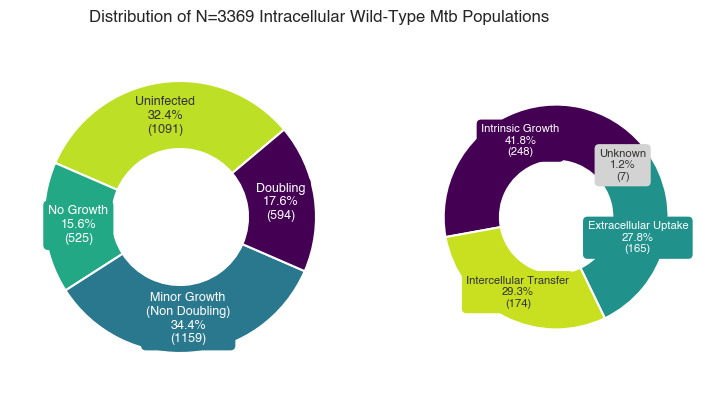

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

# --- Data & Control Variables ---
origin_palette_list = ['#440154', '#21918c', '#c8e020'] 

# Configuration
plt.rcParams['font.family'] = 'Helvetica'
viridis = plt.cm.viridis

# Main plot colors
colors_main = [viridis(0.9), viridis(0.6), viridis(0.4), origin_palette_list[0]] 

# Breakout colors: Intrinsic (0), Transfer (2), Uptake (1), Unknown (Light Grey)
colors_breakout = [origin_palette_list[0], origin_palette_list[2], origin_palette_list[1], '#D3D3D3']

def get_text_color(color):
    """Calculates contrast text color (white/dark grey) for both Hex and RGBA."""
    rgb = to_rgb(color) 
    brightness = (rgb[0] * 299 + rgb[1] * 587 + rgb[2] * 114) / 1000
    return 'white' if brightness < 0.5 else '#333333'

def draw_styled_donut(ax, sizes, labels, colors, font_scale=1.0):
    wedges, _ = ax.pie(
        sizes, 
        colors=colors, 
        startangle=40,
        wedgeprops=dict(width=0.5, edgecolor='w', linewidth=1.5)
    )
    
    for i, p in enumerate(wedges):
        # Skip labels for empty slices (just in case)
        if sizes[i] == 0: continue
            
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.radians(ang))
        x = np.cos(np.radians(ang))
        
        current_color = colors[i]
        text_color = get_text_color(current_color)
        percentage = (sizes[i]/sum(sizes))*100
        
        label_text = f"{labels[i]}\n{percentage:.1f}%\n({sizes[i]})"
        
        # Sitting at r=0.75 relative to the wedge
        ax.annotate(
            label_text, 
            xy=(x, y), 
            xytext=(0.75*x, 0.75*y),
            ha='center', va='center',
            color=text_color,
            fontsize=9 * font_scale,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc=current_color, ec="none", alpha=1)
        )

# Create layout with width_ratios to make the right panel smaller
fig, (ax_main, ax_breakout) = plt.subplots(1, 2, figsize=(8, 4), 
                                           gridspec_kw={'width_ratios': [1.75, 1]})
fig.patch.set_facecolor('white')

# 1. Main Pie (Left)
draw_styled_donut(ax_main, 
                  [N_uninfected, N_no_growth, N_minor_growth, N_doubling], 
                  ['Uninfected', 'No Growth', 'Minor Growth\n(Non Doubling)', 'Doubling'], 
                  colors_main)

# 2. Breakout Pie (Right) - Now includes N_unknown
draw_styled_donut(ax_breakout, 
                  [N_intrinsic, N_transfer, N_uptake, N_unknown], 
                  ['Intrinsic Growth', 'Intercellular Transfer', 'Extracellular Uptake', 'Unknown'], 
                  colors_breakout,
                  font_scale=0.9) # Slightly smaller font to accommodate the 4th slice

plt.suptitle(f"Distribution of N={N_tracks} Intracellular Wild-Type Mtb Populations", 
             y=0.98, fontsize=12, fontweight='bold')

plt.tight_layout()

# save_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/wt_growth_piecharts.pdf'
# plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show()

## Now rd1

In [83]:
import numpy as np
import pandas as pd

# --- Data Cleaning & Categorisation ---
# 1. Isolate the target population (e.g., WT CTRL)
subset_df = df[(df['Strain'] == 'RD1') & (df['Compound'] == 'CTRL')].copy()

# 2. Calculate cumulative infected duration per ID
inf_dur = subset_df[subset_df['Infection Status'] == 1].groupby('ID')['dt'].sum()
infected_ids = inf_dur[inf_dur >= 10].index

# 3. Create a unique track dataframe for metadata mapping
unique_tracks = subset_df.drop_duplicates('ID').set_index('ID')

# 4. Main Categories
N_tracks = len(unique_tracks)
N_infected = len(infected_ids)
N_uninfected = N_tracks - N_infected

# 5. Partition the Infected Population
# Doubling population (Checked tracks excluding 'Junk')
doubling_mask = (unique_tracks.index.isin(infected_ids)) & \
                (unique_tracks['mtb_origin'].notna()) & \
                (unique_tracks['mtb_origin'] != 'Junk')
doubling_df = unique_tracks[doubling_mask]
N_doubling = len(doubling_df)

# Subcategories of Doubling
N_intrinsic = len(doubling_df[doubling_df['mtb_origin'] == 'Growth'])
N_transfer = len(doubling_df[doubling_df['mtb_origin'] == 'Transfer'])
N_uptake = len(doubling_df[doubling_df['mtb_origin'] == 'Uptake'])

# Remaining infected are 'Minor' or 'No' growth
remaining_infected_df = unique_tracks[
    (unique_tracks.index.isin(infected_ids)) & (~doubling_mask)
]

N_minor_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] > 0])
N_no_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] <= 0])

# --- Summary Output ---
print(f"Total: {N_tracks} | Uninfected: {N_uninfected} | Infected: {N_infected}")
print(f"  - Doubling: {N_doubling} (Intrinsic: {N_intrinsic}, Transfer: {N_transfer}, Uptake: {N_uptake})")
print(f"  - Minor Growth: {N_minor_growth} | No Growth: {N_no_growth}")

Total: 1546 | Uninfected: 764 | Infected: 782
  - Doubling: 191 (Intrinsic: 83, Transfer: 34, Uptake: 67)
  - Minor Growth: 372 | No Growth: 219


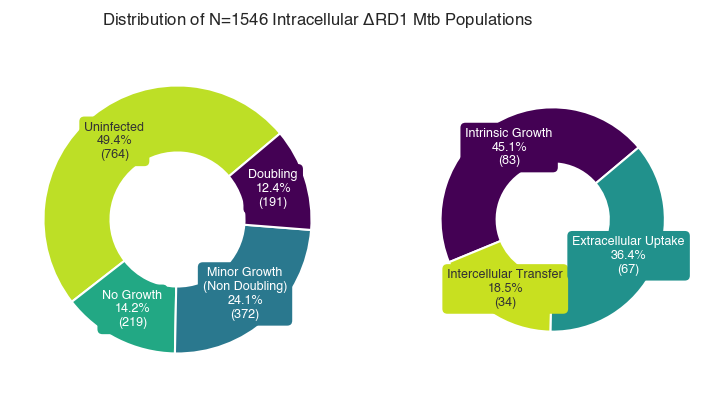

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

# --- Data & Control Variables ---
origin_palette_list = ['#440154', '#21918c', '#c8e020'] 

# Configuration
plt.rcParams['font.family'] = 'Helvetica'
viridis = plt.cm.viridis

# Main plot colors
colors_main = [viridis(0.9), viridis(0.6), viridis(0.4), origin_palette_list[0]] 

# Breakout colors: Intrinsic (0), Transfer (2), Uptake (1)
colors_breakout = [origin_palette_list[0], origin_palette_list[2], origin_palette_list[1]]

def get_text_color(color):
    """Calculates contrast text color (white/dark grey) for both Hex and RGBA."""
    rgb = to_rgb(color) 
    brightness = (rgb[0] * 299 + rgb[1] * 587 + rgb[2] * 114) / 1000
    return 'white' if brightness < 0.5 else '#333333'

def draw_styled_donut(ax, sizes, labels, colors, font_scale=1.0):
    wedges, _ = ax.pie(
        sizes, 
        colors=colors, 
        startangle=40,
        wedgeprops=dict(width=0.5, edgecolor='w', linewidth=1.5)
    )
    
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.radians(ang))
        x = np.cos(np.radians(ang))
        
        current_color = colors[i]
        text_color = get_text_color(current_color)
        percentage = (sizes[i]/sum(sizes))*100
        
        label_text = f"{labels[i]}\n{percentage:.1f}%\n({sizes[i]})"
        
        # Sitting at r=0.75 relative to the wedge
        ax.annotate(
            label_text, 
            xy=(x, y), 
            xytext=(0.75*x, 0.75*y),
            ha='center', va='center',
            color=text_color,
            fontsize=9 * font_scale,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc=current_color, ec="none", alpha=1)
        )

# Create layout with width_ratios to make the right panel smaller
# 1.5 : 1 ratio makes the right roughly 2/3 the width of the left
fig, (ax_main, ax_breakout) = plt.subplots(1, 2, figsize=(8, 4), 
                                           gridspec_kw={'width_ratios': [1.75, 1]})
fig.patch.set_facecolor('white')

# 1. Main Pie (Left)
draw_styled_donut(ax_main, 
                  [N_uninfected, N_no_growth, N_minor_growth, N_doubling], 
                  ['Uninfected', 'No Growth', 'Minor Growth\n(Non Doubling)', 'Doubling'], 
                  colors_main)

# 2. Breakout Pie (Right) - Reduced font slightly for the smaller chart
draw_styled_donut(ax_breakout, 
                  [N_intrinsic, N_transfer, N_uptake], 
                  ['Intrinsic Growth', 'Intercellular Transfer', 'Extracellular Uptake'], 
                  colors_breakout,
                  font_scale=1)

plt.suptitle(r"Distribution of N={} Intracellular $\Delta$RD1 Mtb Populations".format(N_tracks), 
             y=0.98, fontsize=12, fontweight='bold')

plt.tight_layout()

# Save with your specific path
save_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/rd1_growth_piecharts.pdf'
# Note: Ensure the directory exists or wrap in a try-block if working locally
plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show()

### Now atbs

In [86]:
import numpy as np
import pandas as pd

# --- Data Cleaning & Categorisation ---
# 1. Isolate the target population (e.g., WT CTRL)
subset_df = df[(df['Strain'] == 'WT') & (df['Compound'] != 'CTRL')].copy()

# 2. Calculate cumulative infected duration per ID
inf_dur = subset_df[subset_df['Infection Status'] == 1].groupby('ID')['dt'].sum()
infected_ids = inf_dur[inf_dur >= 10].index

# 3. Create a unique track dataframe for metadata mapping
unique_tracks = subset_df.drop_duplicates('ID').set_index('ID')

# 4. Main Categories
N_tracks = len(unique_tracks)
N_infected = len(infected_ids)
N_uninfected = N_tracks - N_infected

# 5. Partition the Infected Population
# Doubling population (Checked tracks excluding 'Junk')
doubling_mask = (unique_tracks.index.isin(infected_ids)) & \
                (unique_tracks['mtb_origin'].notna()) & \
                (unique_tracks['mtb_origin'] != 'Junk')
doubling_df = unique_tracks[doubling_mask]
N_doubling = len(doubling_df)

# Subcategories of Doubling
N_intrinsic = len(doubling_df[doubling_df['mtb_origin'] == 'Growth'])
N_transfer = len(doubling_df[doubling_df['mtb_origin'] == 'Transfer'])
N_uptake = len(doubling_df[doubling_df['mtb_origin'] == 'Uptake'])

# Remaining infected are 'Minor' or 'No' growth
remaining_infected_df = unique_tracks[
    (unique_tracks.index.isin(infected_ids)) & (~doubling_mask)
]

N_minor_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] > 0])
N_no_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] <= 0])

# --- Summary Output ---
print(f"Total: {N_tracks} | Uninfected: {N_uninfected} | Infected: {N_infected}")
print(f"  - Doubling: {N_doubling} (Intrinsic: {N_intrinsic}, Transfer: {N_transfer}, Uptake: {N_uptake})")
print(f"  - Minor Growth: {N_minor_growth} | No Growth: {N_no_growth}")

Total: 10939 | Uninfected: 3522 | Infected: 7417
  - Doubling: 847 (Intrinsic: 246, Transfer: 252, Uptake: 318)
  - Minor Growth: 2859 | No Growth: 2175


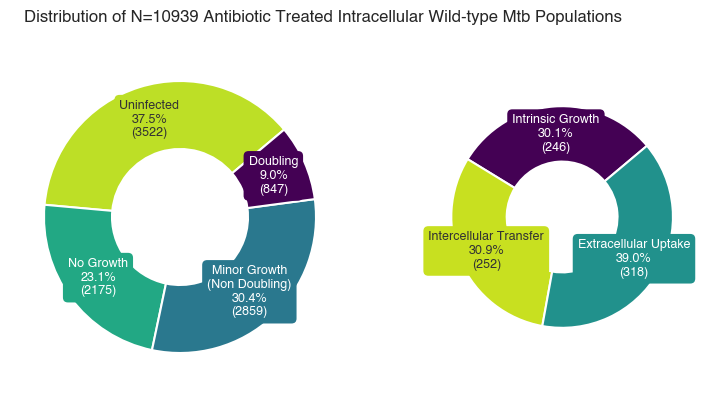

In [87]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

# --- Data & Control Variables ---
origin_palette_list = ['#440154', '#21918c', '#c8e020'] 

# Configuration
plt.rcParams['font.family'] = 'Helvetica'
viridis = plt.cm.viridis

# Main plot colors
colors_main = [viridis(0.9), viridis(0.6), viridis(0.4), origin_palette_list[0]] 

# Breakout colors: Intrinsic (0), Transfer (2), Uptake (1)
colors_breakout = [origin_palette_list[0], origin_palette_list[2], origin_palette_list[1]]

def get_text_color(color):
    """Calculates contrast text color (white/dark grey) for both Hex and RGBA."""
    rgb = to_rgb(color) 
    brightness = (rgb[0] * 299 + rgb[1] * 587 + rgb[2] * 114) / 1000
    return 'white' if brightness < 0.5 else '#333333'

def draw_styled_donut(ax, sizes, labels, colors, font_scale=1.0):
    wedges, _ = ax.pie(
        sizes, 
        colors=colors, 
        startangle=40,
        wedgeprops=dict(width=0.5, edgecolor='w', linewidth=1.5)
    )
    
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.radians(ang))
        x = np.cos(np.radians(ang))
        
        current_color = colors[i]
        text_color = get_text_color(current_color)
        percentage = (sizes[i]/sum(sizes))*100
        
        label_text = f"{labels[i]}\n{percentage:.1f}%\n({sizes[i]})"
        
        # Sitting at r=0.75 relative to the wedge
        ax.annotate(
            label_text, 
            xy=(x, y), 
            xytext=(0.75*x, 0.75*y),
            ha='center', va='center',
            color=text_color,
            fontsize=9 * font_scale,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc=current_color, ec="none", alpha=1)
        )

# Create layout with width_ratios to make the right panel smaller
# 1.5 : 1 ratio makes the right roughly 2/3 the width of the left
fig, (ax_main, ax_breakout) = plt.subplots(1, 2, figsize=(8, 4), 
                                           gridspec_kw={'width_ratios': [1.75, 1]})
fig.patch.set_facecolor('white')

# 1. Main Pie (Left)
draw_styled_donut(ax_main, 
                  [N_uninfected, N_no_growth, N_minor_growth, N_doubling], 
                  ['Uninfected', 'No Growth', 'Minor Growth\n(Non Doubling)', 'Doubling'], 
                  colors_main)

# 2. Breakout Pie (Right) - Reduced font slightly for the smaller chart
draw_styled_donut(ax_breakout, 
                  [N_intrinsic, N_transfer, N_uptake], 
                  ['Intrinsic Growth', 'Intercellular Transfer', 'Extracellular Uptake'], 
                  colors_breakout,
                  font_scale=1)

plt.suptitle(r"Distribution of N={} Antibiotic Treated Intracellular Wild-type Mtb Populations".format(N_tracks), 
             y=0.98, fontsize=12, fontweight='bold')

plt.tight_layout()

# Save with your specific path
save_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/wt_atbs_growth_piecharts.pdf'
# Note: Ensure the directory exists or wrap in a try-block if working locally
plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show()

### Rd1 atbs

In [88]:
import numpy as np
import pandas as pd

# --- Data Cleaning & Categorisation ---
# 1. Isolate the target population (e.g., WT CTRL)
subset_df = df[(df['Strain'] == 'RD1') & (df['Compound'] != 'CTRL')].copy()

# 2. Calculate cumulative infected duration per ID
inf_dur = subset_df[subset_df['Infection Status'] == 1].groupby('ID')['dt'].sum()
infected_ids = inf_dur[inf_dur >= 10].index

# 3. Create a unique track dataframe for metadata mapping
unique_tracks = subset_df.drop_duplicates('ID').set_index('ID')

# 4. Main Categories
N_tracks = len(unique_tracks)
N_infected = len(infected_ids)
N_uninfected = N_tracks - N_infected

# 5. Partition the Infected Population
# Doubling population (Checked tracks excluding 'Junk')
doubling_mask = (unique_tracks.index.isin(infected_ids)) & \
                (unique_tracks['mtb_origin'].notna()) & \
                (unique_tracks['mtb_origin'] != 'Junk')
doubling_df = unique_tracks[doubling_mask]
N_doubling = len(doubling_df)

# Subcategories of Doubling
N_intrinsic = len(doubling_df[doubling_df['mtb_origin'] == 'Growth'])
N_transfer = len(doubling_df[doubling_df['mtb_origin'] == 'Transfer'])
N_uptake = len(doubling_df[doubling_df['mtb_origin'] == 'Uptake'])

# Remaining infected are 'Minor' or 'No' growth
remaining_infected_df = unique_tracks[
    (unique_tracks.index.isin(infected_ids)) & (~doubling_mask)
]

N_minor_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] > 0])
N_no_growth = len(remaining_infected_df[remaining_infected_df['dMtb Area (µm)'] <= 0])

# --- Summary Output ---
print(f"Total: {N_tracks} | Uninfected: {N_uninfected} | Infected: {N_infected}")
print(f"  - Doubling: {N_doubling} (Intrinsic: {N_intrinsic}, Transfer: {N_transfer}, Uptake: {N_uptake})")
print(f"  - Minor Growth: {N_minor_growth} | No Growth: {N_no_growth}")

Total: 3029 | Uninfected: 1592 | Infected: 1437
  - Doubling: 100 (Intrinsic: 8, Transfer: 27, Uptake: 63)
  - Minor Growth: 677 | No Growth: 660


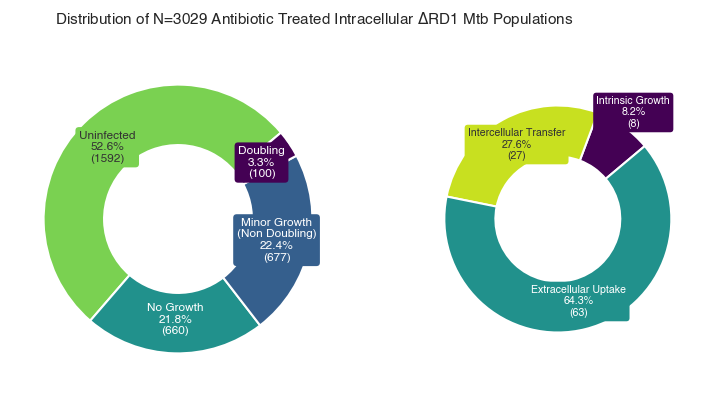

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

# --- Data & Control Variables ---
origin_palette_list = ['#440154', '#21918c', '#c8e020'] 

# Configuration
plt.rcParams['font.family'] = 'Helvetica'
viridis = plt.cm.viridis
colors_main = [viridis(0.8), viridis(0.5), viridis(0.3), origin_palette_list[0]] 
colors_breakout = [origin_palette_list[0], origin_palette_list[2], origin_palette_list[1]]

def get_text_color(color):
    rgb = to_rgb(color) 
    brightness = (rgb[0] * 299 + rgb[1] * 587 + rgb[2] * 114) / 1000
    return 'white' if brightness < 0.5 else '#333333'

def draw_styled_donut(ax, sizes, labels, colors, font_scale=1.0, offsets=None):
    wedges, _ = ax.pie(
        sizes, 
        colors=colors, 
        startangle=40,
        wedgeprops=dict(width=0.45, edgecolor='w', linewidth=1.5)
    )
    
    if offsets is None:
        offsets = [0.75] * len(sizes)
    
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.radians(ang))
        x = np.cos(np.radians(ang))
        
        current_color = colors[i]
        text_color = get_text_color(current_color)
        percentage = (sizes[i]/sum(sizes))*100
        
        label_text = f"{labels[i]}\n{percentage:.1f}%\n({sizes[i]})"
        
        # Use the specific offset for this wedge to prevent overlap
        r_dist = offsets[i]
        
        ax.annotate(
            label_text, 
            xy=(x, y), 
            xytext=(r_dist*x, r_dist*y),
            ha='center', va='center',
            color=text_color,
            fontsize=8.5 * font_scale,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc=current_color, ec="none", alpha=1)
        )

# Create layout
fig, (ax_main, ax_breakout) = plt.subplots(1, 2, figsize=(8, 4), 
                                           gridspec_kw={'width_ratios': [1.75, 1]})
fig.patch.set_facecolor('white')

# 1. Main Pie (Standard internal offsets)
draw_styled_donut(ax_main, 
                  [N_uninfected, N_no_growth, N_minor_growth, N_doubling], 
                  ['Uninfected', 'No Growth', 'Minor Growth\n(Non Doubling)', 'Doubling'], 
                  colors_main)

# 2. Breakout Pie (Manual offsets to prevent overlap)
# Intrinsic and Transfer are small/adjacent, so we push Intrinsic further out
# Indices: [Intrinsic, Transfer, Uptake]
breakout_offsets = [1.15, 0.75, 0.75] 

draw_styled_donut(ax_breakout, 
                  [N_intrinsic, N_transfer, N_uptake], 
                  ['Intrinsic Growth', 'Intercellular Transfer', 'Extracellular Uptake'], 
                  colors_breakout,
                  font_scale=0.9,
                  offsets=breakout_offsets)

plt.suptitle(r"Distribution of N={} Antibiotic Treated Intracellular $\Delta$RD1 Mtb Populations".format(N_tracks), 
             y=0.98, fontsize=11, fontweight='bold')

plt.tight_layout()

# Save path
save_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/rd1_atbs_growth_piecharts.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show()

# Now the correlations

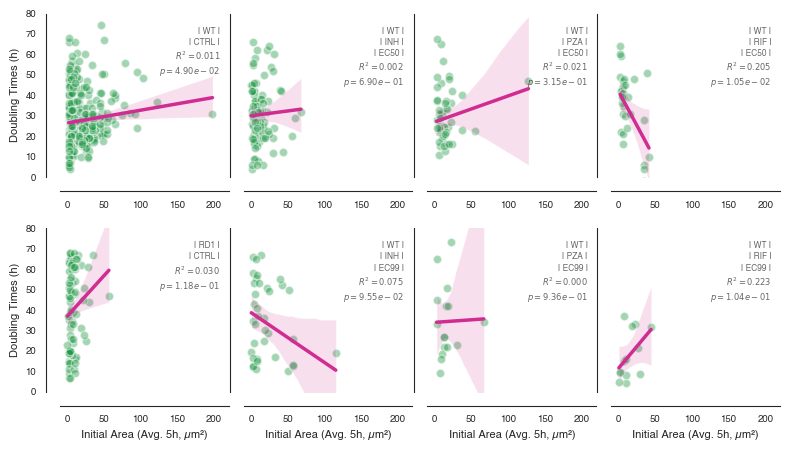

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import linregress

# --- 1. Data Preparation: Averaged Initial Area ---
# Filtering for timepoints <= 5h to calculate the average initial area
df_10h = df[df['Time (hours)'] <= 5]
avg_area_map = df_10h.groupby('ID')['Mtb Area (µm)'].mean().rename('Avg_Initial_Area_10h')

# Isolating growth population and handling list-like doubling times via explode
subset_df = df[df['mtb_origin'] == 'Growth'].copy()
subset_df = subset_df.drop_duplicates('ID')
subset_df = subset_df.explode('Doubling Times')

# Merging averaged metric into the unique-track dataframe
plot_df = subset_df.merge(avg_area_map, on='ID', how='left')

# Ensuring numeric types for regression analysis
plot_df['Doubling Times'] = pd.to_numeric(plot_df['Doubling Times'], errors='coerce')
plot_df['Avg_Initial_Area_10h'] = pd.to_numeric(plot_df['Avg_Initial_Area_10h'], errors='coerce')

plot_df = plot_df.dropna(subset=['Doubling Times', 'Avg_Initial_Area_10h'])

# --- 2. Define the Grid Logic ---
# Conditions matching the specified manuscript layout
grid_conditions = [
    ('WT', 'CTRL', None), ('WT', 'INH', 'EC50'), ('WT', 'PZA', 'EC50'), ('WT', 'RIF', 'EC50'),
    ('RD1', 'CTRL', None), ('WT', 'INH', 'EC99'), ('WT', 'PZA', 'EC99'), ('WT', 'RIF', 'EC99')
]

# --- 3. Visualization ---
plt.rcParams['font.family'] = 'Helvetica'
# Adjusted for ~200mm A4 width
fig, axes = plt.subplots(2, 4, figsize=(8, 5), sharey=True, sharex=False)
axes = axes.flatten()

for i, (strain, compound, conc) in enumerate(grid_conditions):
    ax = axes[i]
    
    mask = (plot_df['Strain'] == strain) & (plot_df['Compound'] == compound)
    if conc:
        mask &= (plot_df['Concentration'] == conc)
    
    data_sub = plot_df[mask].copy()
    
    if len(data_sub) > 2:  
        # Plotting regression with specified line color and thickness
        sns.regplot(
            data=data_sub, x='Avg_Initial_Area_10h', y='Doubling Times',
            ax=ax, scatter_kws={'alpha': 0.4, 'color': '#1a9641', 'edgecolor': 'w'},
            line_kws={'color': '#d02c91', 'lw': 2.5}
        )
        
        # Calculating linear regression statistics
        slope, intercept, r_value, p_value, std_err = linregress(
            data_sub['Avg_Initial_Area_10h'], data_sub['Doubling Times']
        )
        
        # Creating a combined text block for condition and statistics
        if conc:
            label_stack = f"| {strain} |\n| {compound} |\n| {conc} |"
        else:
            label_stack = f"| {strain} |\n| {compound} |"
        
        stats_stack = f"\n$R^2 = {r_value**2:.3f}$\n$p = {p_value:.2e}$"
        combined_text = label_stack + stats_stack
            
        # Placing the combined block in the top-right
        ax.text(0.95, 0.92, combined_text, transform=ax.transAxes, verticalalignment='top', 
                horizontalalignment='right', fontsize=6, alpha=0.7, linespacing=1.3)

    # Formatting axes and labels
    ax.set_ylim(0, 80)
    ax.set_xlim(-10, 220)
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    ax.set_xlabel('Initial Area (Avg. 5h, µm²)' if i >= 4 else '', fontsize=8)
    ax.set_ylabel('Doubling Times (h)' if i % 4 == 0 else '', fontsize=8)
    
    sns.despine(ax=ax, offset=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/supp/intial_area_vs_dt_correlation_S1E.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show()